# Independent Component Analysis (ICA)

Independent Component Analysis (ICA) is a technique used to separate mixed signals into their independent, non-Gaussian components.

ICA operates under two key assumptions:

- The source signals are statistically independent of each other.
- The source signals have non-Gaussian distributions.

# Cocktail Party Problem in ICA

Here there is a party going into a room full of people.

- There is 'n' number of speakers in that room and they are speaking simultaneously at the party.
- In the same room, there are also 'n' microphones placed at different distances from the speakers which are recording 'n' speakers' voice signals.

Hence the number of speakers is equal to the number of microphones in the room. Now using these microphones' recordings, we want to separate all the 'n' speakers voice signals in the room given that each microphone recorded the voice signals coming from each speaker of different intensity due to the difference in distances between them.

In [1]:
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt

In [3]:
# Generate Random Data and Mix the Signals
# In this step we create three separate signals: a sine wave, a square wave and random noise. These represent different types of real-world signals. We use NumPy to generate 200 time points between 0 and 8.
# signal_1: A sine wave like a tuning fork tone.
# signal_2: A square wave like a digital signal (on/off).
# signal_3: A random noise signal using the Laplace distribution which has sharper peaks than normal distribution.
# np.c_[]: Combine all three 1D signals into a single 2D array.
# 0.2 is the standard deviation of the noise

np.random.seed(42)
samples = 200
time = np.linspace(0, 8, samples)

signal_1 = np.sin(2 * time)
signal_2 = np.sign(np.sin(3 * time))
signal_3 = np.random.laplace(size=samples)

S = np.c_[signal_1, signal_2, signal_3]
S += 0.2 * np.random.normal(size=S.shape)

A = np.array([[1, 1, 1], [0.5, 2, 1], [1.5, 1, 2]])
X = S.dot(A.T)

In [4]:
# Apply ICA to unmix the signals

ica = FastICA(n_components=3)
S_ = ica.fit_transform(X)

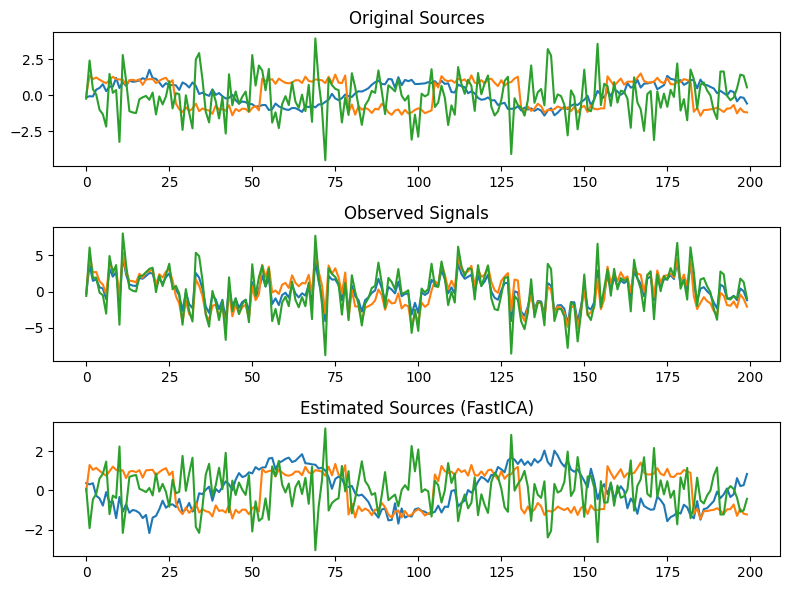

In [6]:
# Visualize the signals

plt.figure(figsize=(8, 6))

plt.subplot(3, 1, 1)
plt.title('Original Sources')
plt.plot(S)

plt.subplot(3, 1, 2)
plt.title('Observed Signals')
plt.plot(X)

plt.subplot(3, 1, 3)
plt.title('Estimated Sources (FastICA)')
plt.plot(S_)

plt.tight_layout()
plt.show()